In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import imageio

# --- CONFIG ---
# Pick a raw NeRSemble mp4 here (full resolution), e.g. one camera of 017
video_path = Path("/home/piado/scratch/data/nersemble/017/sequences/EMO-1-shout+laugh/images/cam_220700191.mp4")
# Where to save the extracted PNG inside the repo
repo_root = Path("/home/piado/projects/aip-lindell/piado")
extracted_png = repo_root / "data/processing/debug_rvm_src.png"

# RobustVideoMatting checkpoint inside the repo
checkpoint_path = repo_root / "data/rvm_mobilenetv3.pth"
rvm_root = repo_root / "RobustVideoMatting"
# ---------------

print(f"Video path: {video_path}")
print(f"Extracted PNG will be saved to: {extracted_png}")
print(f"Checkpoint: {checkpoint_path}")

assert video_path.exists(), f"Missing video: {video_path}"
assert checkpoint_path.exists(), f"Missing checkpoint: {checkpoint_path}"

# Extract a single frame (middle frame) from the mp4 at ORIGINAL resolution
reader = imageio.get_reader(str(video_path))
try:
    n_frames = reader.count_frames()
except Exception:
    # Fallback if count_frames is not implemented
    n_frames = sum(1 for _ in reader)
    reader.set_image_index(0)

frame_idx = max(0, n_frames // 2)
print(f"Total frames: {n_frames}, using frame index: {frame_idx}")
frame = reader.get_data(frame_idx)
reader.close()

img_pil = Image.fromarray(frame).convert("RGB")
img_pil.save(extracted_png)
print(f"Saved extracted frame to {extracted_png}")

# This is the image we will run RVM on
image_path = extracted_png

# Ensure RobustVideoMatting is importable
if str(rvm_root) not in sys.path:
    sys.path.insert(0, str(rvm_root))

from model import MattingNetwork

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load RVM model
model = MattingNetwork(variant="mobilenetv3").to(device).eval()
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

print("Model loaded.")
print(f"Using image: {image_path}")

Video path: /home/piado/scratch/data/nersemble/017/sequences/EMO-1-shout+laugh/images/cam_220700191.mp4
Extracted PNG will be saved to: /home/piado/projects/aip-lindell/piado/data/processing/debug_rvm_src.png
Checkpoint: /home/piado/projects/aip-lindell/piado/data/rvm_mobilenetv3.pth
Total frames: 383, using frame index: 191
Saved extracted frame to /home/piado/projects/aip-lindell/piado/data/processing/debug_rvm_src.png
Using device: cpu
Model loaded.
Using image: /home/piado/projects/aip-lindell/piado/data/processing/debug_rvm_src.png


Original resolution: 2200x3208


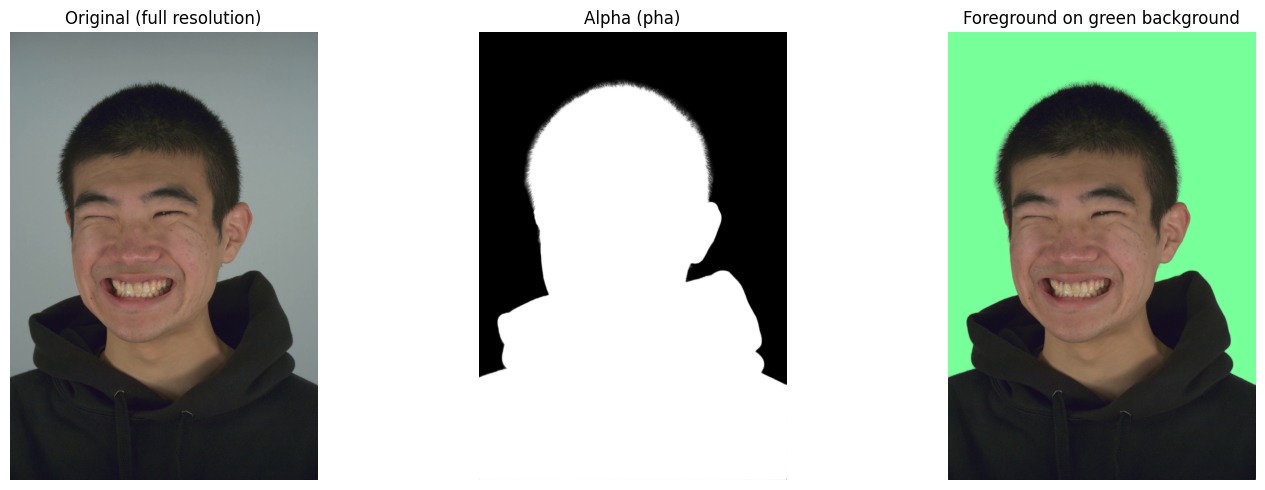

In [2]:
# Run background removal at ORIGINAL resolution and visualize green background

# Load image at original resolution
img_pil = Image.open(image_path).convert("RGB")
orig_w, orig_h = img_pil.size
print(f"Original resolution: {orig_w}x{orig_h}")

# Convert to tensor [1, 3, H, W] in 0-1 range
img_np = np.asarray(img_pil).astype(np.float32) / 255.0
src = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(device)

# Initial recurrent states
rec = [None] * 4

with torch.no_grad():
    # Use a moderate downsample ratio, but DO NOT resize input beforehand.
    # The model will see the original resolution frames.
    fgr, pha, *rec = model(src, *rec, downsample_ratio=0.25)

# fgr, pha are [1, 3, H, W] and [1, 1, H, W] in 0-1 range

# Green background
bgr = torch.tensor([0.47, 1.0, 0.6], device=device).view(1, 3, 1, 1)

# Composite: foreground on green background
comp = fgr * pha + bgr * (1 - pha)

# Move to CPU for visualization
orig_vis = src[0].clamp(0, 1).permute(1, 2, 0).cpu().numpy()
pha_vis = pha[0, 0].clamp(0, 1).cpu().numpy()
comp_vis = comp[0].clamp(0, 1).permute(1, 2, 0).cpu().numpy()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_vis)
axes[0].set_title("Original (full resolution)")
axes[0].axis("off")

axes[1].imshow(pha_vis, cmap="gray")
axes[1].set_title("Alpha (pha)")
axes[1].axis("off")

axes[2].imshow(comp_vis)
axes[2].set_title("Foreground on green background")
axes[2].axis("off")

plt.tight_layout()
plt.show()




# DONE

In [1]:
from pathlib import Path
import tempfile

from PIL import Image
import matplotlib.pyplot as plt
import torch

from preprocess_nersemble import remove_background, Converter

# Paths
png_path = Path("/home/piado/projects/aip-lindell/piado/data/processing/check_pt_debug/v0_t0.png")
checkpoint_path = Path("/home/piado/projects/aip-lindell/piado/data/rvm_mobilenetv3.pth")
device = "cuda" if torch.cuda.is_available() else "cpu"

png_path, checkpoint_path, device

/home/piado/projects/aip-lindell/piado/snth/lib/python3.11/site-packages/colour/utilities/verbose.py:340: ColourUsageWarning: "SciPy" related API features are not available: "No module named 'scipy'".
See the installation guide for more information: https://www.colour-science.org/installation-guide/
  warn(*args, **kwargs)


(PosixPath('/home/piado/projects/aip-lindell/piado/data/processing/check_pt_debug/v0_t0.png'),
 PosixPath('/home/piado/projects/aip-lindell/piado/data/rvm_mobilenetv3.pth'),
 'cpu')

In [2]:
# Create background removal model and prepare frames
assert png_path.exists(), f"PNG not found: {png_path}"
assert checkpoint_path.exists(), f"Checkpoint not found: {checkpoint_path}"

matting_model = Converter("mobilenetv3", str(checkpoint_path), device)
print("Loaded Converter on", device)

# Load image and replicate to form a small video
orig_img = Image.open(png_path).convert("RGB")
frames = [orig_img.copy() for _ in range(16)]  # 16 identical frames

# Temporary directory for intermediate video files
temp_dir = Path(tempfile.mkdtemp(prefix="bg_debug_"))
print("Temp dir:", temp_dir)

processed_frames = remove_background(frames, matting_model, temp_dir, "debug_single")

orig_frame = frames[0]
proc_frame = processed_frames[0] if processed_frames else orig_frame

Loaded Converter on cpu
Temp dir: /tmp/bg_debug_qw3b5l6k


/home/piado/projects/aip-lindell/piado/snth/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✓ Background removal successful for debug_single (16 frames)


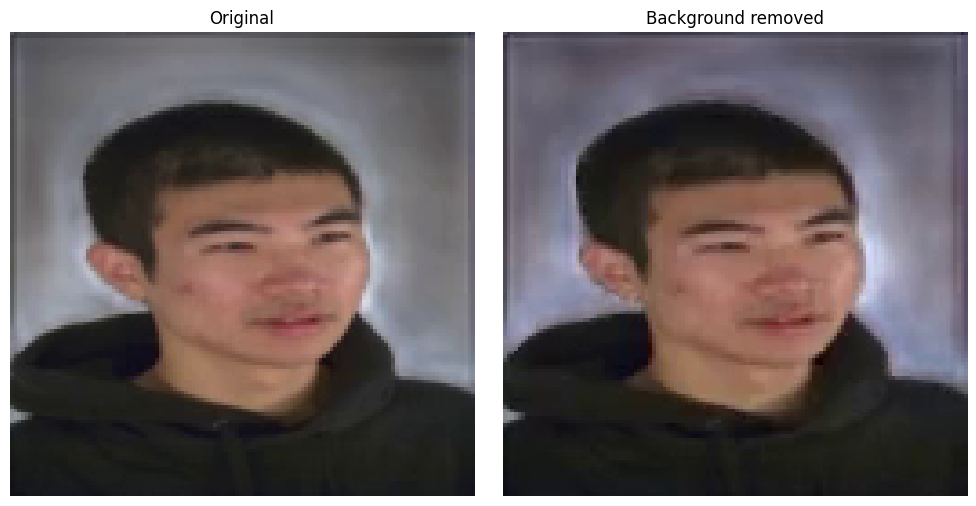

In [4]:
# Show original vs background-removed frame
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(orig_frame)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(proc_frame)
axes[1].set_title("Background removed")
axes[1].axis("off")

plt.tight_layout()
plt.show()